# Kiểm chứng tín hiệu sinh lý rPPG — trả lời góp ý phản biện ICTA 2026 (mục A3)

**Trích nguyên văn góp ý Phản biện 1, bài báo #314:**
> *"Bài báo không cung cấp đồ thị dạng sóng mạch (pulse traces), phổ tần số, ước tính nhịp tim
> hay chất lượng tín hiệu sinh lý. Nhánh này có thể chỉ đang học các yếu tố nhiễu về màu sắc,
> chuyển động, nén dữ liệu hoặc đặc trưng riêng của dataset thay vì các tín hiệu sinh học thực
> chất."*

## Notebook này làm gì
**Đây KHÔNG phải notebook train.** Đây là bước **phân tích/kiểm chứng độc lập, chạy SAU khi đã
có cache** `ffpp-c23-rppg-cache` — không đụng vào model, không cần checkpoint, không train lại
bất cứ thứ gì. Notebook trích xuất tín hiệu rPPG bằng phương pháp cổ điển (Green-channel — chuẩn
tham chiếu phổ biến trong y sinh, Verkruysse et al. 2008) trực tiếp từ ảnh khuôn mặt đã crop sẵn
trong cache, để trả lời đúng 4 ý phản biện yêu cầu:

1. **Đồ thị dạng sóng mạch (pulse traces)** — Mục 4.
2. **Phổ tần số (frequency spectrum)** — Mục 4.
3. **Ước tính nhịp tim (heart rate)** — Mục 4.
4. **Chất lượng tín hiệu (signal quality)** — đo bằng tỉ lệ năng lượng trong dải sinh lý
   (in-band power ratio, một dạng SNR) — Mục 5, tính trên **nhiều video** (không phải 1 ví dụ
   đơn lẻ như Hình 5 cũ bị phản biện chê).

**Điểm mấu chốt:** ngoài tín hiệu Green-channel cổ điển (tham chiếu độc lập với model), notebook
còn trích **đúng tín hiệu `mot` (frame-difference chuẩn hoá)** — chính là thứ nhánh rPPG của bạn
**thực sự nhận làm đầu vào** — để trả lời trực tiếp nghi ngờ *"nhánh này có thể chỉ học nhiễu...
thay vì tín hiệu sinh học"*: nếu phổ tần số của `mot` cũng có đỉnh rơi đúng dải nhịp tim
(0.7–4 Hz), đó là bằng chứng mạnh cho thấy input mà model dùng thực sự mang thông tin sinh lý.

## Cơ sở kỹ thuật đã xác nhận từ `prepare-data-rppg_22072026_v1.ipynb`
- Cache trích **240 khung hình LIÊN TỤC** (không cách đều) quanh giữa mỗi video, dùng **1
  bounding box cố định** cho cả đoạn (tránh nhiễu do box nhảy — quan trọng để tín hiệu motion
  không lẫn nhiễu chuyển động do dò lại mặt mỗi frame).
- **`fps` THỰC TẾ của từng video được lưu sẵn trong `manifest_processed.csv`** (đọc bằng
  `cv2.CAP_PROP_FPS`) — notebook này dùng đúng fps thật theo từng video, **không giả định hằng
  số 25fps chung cho tất cả**.


## 1. Cấu hình

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import signal as sig
from scipy import stats as spstats
import warnings
warnings.filterwarnings("ignore")

# ==================== ĐƯỜNG DẪN ====================
CACHE_DIR    = "/kaggle/input/datasets/thinhphan272/ffpp-c23-rppg-cache/ffpp_c23_rppg_cache"  # SỬA nếu khác
MANIFEST_CSV = os.path.join(CACHE_DIR, "manifest_processed.csv")
OLD_PREFIX   = "/kaggle/working/ffpp_c23_rppg_cache"
assert os.path.isdir(CACHE_DIR), f"Not found: {CACHE_DIR}"
assert os.path.exists(MANIFEST_CSV), f"Not found: {MANIFEST_CSV}"

# ==================== THAM SỐ SINH LÝ HỌC ====================
HR_BAND_HZ   = (0.7, 4.0)   # dải tần số nhịp tim hợp lệ: 42–240 bpm
MIN_FRAMES   = 64           # video có ít hơn số khung này bị loại (FFT không đủ độ phân giải)
N_EXAMPLE_PAIRS_PER_METHOD = 2    # số cặp real/fake minh hoạ mỗi phương pháp (Mục 4)
N_STATS_REAL   = 150         # số video REAL lấy mẫu cho phân tích thống kê (Mục 5)
N_STATS_PER_METHOD = 40      # số video FAKE mỗi phương pháp lấy mẫu cho Mục 5
SEED = 42
random.seed(SEED); np.random.seed(SEED)

OUT_DIR = "/kaggle/working/rppg_signal_verification"
os.makedirs(OUT_DIR, exist_ok=True)

manifest = pd.read_csv(MANIFEST_CSV)
manifest["out_dir"] = manifest["out_dir"].astype(str).str.replace(OLD_PREFIX, CACHE_DIR, regex=False)
manifest = manifest[manifest["status"].isin(["ok", "partial"])].reset_index(drop=True)  # bỏ "skip_exists" vì fps=None
manifest = manifest[manifest["fps"].notna() & (manifest["n_frames"] >= MIN_FRAMES)].reset_index(drop=True)
print(f"Video đủ điều kiện phân tích (có fps thật + đủ khung hình): {len(manifest)}")
print(f"fps range: {manifest['fps'].min():.2f} — {manifest['fps'].max():.2f}")
print(manifest.groupby(["label", "method"])["video_id"].count())


Video đủ điều kiện phân tích (có fps thật + đủ khung hình): 5000
fps range: 15.00 — 60.00
label  method        
0      original          1000
1      Deepfakes         1000
       Face2Face         1000
       FaceSwap          1000
       NeuralTextures    1000
Name: video_id, dtype: int64


## 2. Chọn cặp video real/fake CÙNG danh tính nguồn

FF++ đặt tên video real dạng `"033"`, video fake dạng `"033_097"` (nguồn_đích). Ghép mỗi video
fake với đúng video real cùng danh tính nguồn để so sánh **trực tiếp, cùng một người**, loại bỏ
khả năng khác biệt chỉ do khác danh tính (đúng tinh thần phản biện 2 mục 3 về identity).

In [2]:
real_df = manifest[manifest.label == 0].set_index("video_id")

def find_source_real(fake_video_id):
    src_id = fake_video_id.split("_")[0]
    return real_df.loc[src_id] if src_id in real_df.index else None

example_pairs = []   # list of (real_row, fake_row, method)
for method in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    fake_rows = manifest[(manifest.label == 1) & (manifest.method == method)].sample(
        frac=1.0, random_state=SEED)
    picked = 0
    for _, frow in fake_rows.iterrows():
        rrow = find_source_real(frow["video_id"])
        if rrow is not None:
            example_pairs.append((rrow, frow, method))
            picked += 1
            if picked >= N_EXAMPLE_PAIRS_PER_METHOD:
                break

print(f"Đã chọn {len(example_pairs)} cặp real/fake cùng danh tính nguồn để minh hoạ:")
for r, f, m in example_pairs:
    print(f"  [{m}] real={r.name} (fps={r['fps']:.2f}) <-> fake={f['video_id']} (fps={f['fps']:.2f})")


Đã chọn 8 cặp real/fake cùng danh tính nguồn để minh hoạ:
  [Deepfakes] real=715 (fps=30.00) <-> fake=715_721 (fps=30.00)
  [Deepfakes] real=126 (fps=30.00) <-> fake=126_104 (fps=30.00)
  [Face2Face] real=715 (fps=30.00) <-> fake=715_721 (fps=30.00)
  [Face2Face] real=126 (fps=30.00) <-> fake=126_104 (fps=30.00)
  [FaceSwap] real=715 (fps=30.00) <-> fake=715_721 (fps=30.00)
  [FaceSwap] real=126 (fps=30.00) <-> fake=126_104 (fps=30.00)
  [NeuralTextures] real=715 (fps=30.00) <-> fake=715_721 (fps=30.00)
  [NeuralTextures] real=126 (fps=30.00) <-> fake=126_104 (fps=30.00)


## 3. Hàm trích tín hiệu rPPG cổ điển + tín hiệu motion (đúng input model dùng)

- **Green-channel signal**: trung bình kênh xanh lá trên toàn vùng mặt mỗi khung hình — phương
  pháp rPPG cổ điển, đơn giản, độc lập hoàn toàn với model (Verkruysse et al., *"Remote
  plethysmographic imaging using ambient light"*, Optics Express 2008).
- **Motion signal**: đúng công thức `compute_normalized_diff` trong notebook train rPPG
  (`(curr - prev) / (curr + prev + eps)`), rồi lấy trung bình toàn khung để ra 1 chuỗi số theo
  thời gian — đại diện cho ĐÚNG những gì nhánh rPPG của bạn nhận làm input `mot`.

In [3]:
DIFF_EPS = 0.01   # khớp đúng DIFF_EPS dùng khi train rPPG v3


def load_clip_frames(out_dir, max_frames=None):
    paths = sorted(glob.glob(os.path.join(out_dir, "*.jpg")))
    if max_frames: paths = paths[:max_frames]
    frames = []
    for p in paths:
        img = cv2.imread(p)
        if img is None: continue
        frames.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32))
    return frames  # list of HxWx3 float32 (0-255)


def green_channel_signal(frames):
    """Tín hiệu rPPG cổ điển: trung bình kênh G toàn khuôn mặt mỗi khung hình."""
    return np.array([f[:, :, 1].mean() for f in frames])


def motion_channel_signal(frames):
    """Đúng công thức compute_normalized_diff trong notebook train rPPG, lấy trung bình
    biên độ mỗi khung -> chuỗi 1D đại diện cho input `mot` thực tế của model."""
    sig_vals = []
    prev = None
    for f in frames:
        cur = f
        if prev is not None:
            c, p = cur / 255.0, prev / 255.0
            diff = (c - p) / (c + p + DIFF_EPS)
            sig_vals.append(np.abs(diff).mean())
        prev = cur
    return np.array(sig_vals)


def bandpass_filter(x, fps, band=HR_BAND_HZ, order=3):
    x = sig.detrend(x)
    nyq = fps / 2.0
    low, high = band[0] / nyq, min(band[1] / nyq, 0.99)
    b, a = sig.butter(order, [low, high], btype="band")
    return sig.filtfilt(b, a, x)


def fft_spectrum(x, fps):
    x = x - x.mean()
    n = len(x)
    freqs = np.fft.rfftfreq(n, d=1.0 / fps)
    power = np.abs(np.fft.rfft(x)) ** 2
    return freqs, power


def estimate_hr_bpm(freqs, power, band=HR_BAND_HZ):
    mask = (freqs >= band[0]) & (freqs <= band[1])
    if not mask.any(): return float("nan")
    peak_freq = freqs[mask][np.argmax(power[mask])]
    return peak_freq * 60.0


def inband_power_ratio(freqs, power, band=HR_BAND_HZ):
    """Tỉ lệ năng lượng nằm trong dải sinh lý / tổng năng lượng -- dùng làm chỉ số chất lượng
    tín hiệu (SNR proxy). Càng cao càng cho thấy tín hiệu tập trung đúng dải sinh lý, không phải
    nhiễu ngẫu nhiên trải đều mọi tần số."""
    mask = (freqs >= band[0]) & (freqs <= band[1])
    total = power.sum()
    if total <= 0: return float("nan")
    return power[mask].sum() / total


print("Đã định nghĩa xong bộ hàm trích/phân tích tín hiệu.")


Đã định nghĩa xong bộ hàm trích/phân tích tín hiệu.


## 4. Ví dụ minh hoạ — sóng mạch, phổ tần số, ước tính nhịp tim (real vs fake cùng danh tính)

Mỗi cặp vẽ 4 panel: (1) sóng Green-channel real vs fake, (2) phổ tần số Green-channel real vs
fake, (3) sóng Motion-signal (đúng input `mot`) real vs fake, (4) phổ tần số Motion-signal.
Vùng tô xanh nhạt = dải tần số nhịp tim hợp lệ (0.7–4 Hz). Chấm đỏ = đỉnh phổ được chọn làm ước
tính nhịp tim.

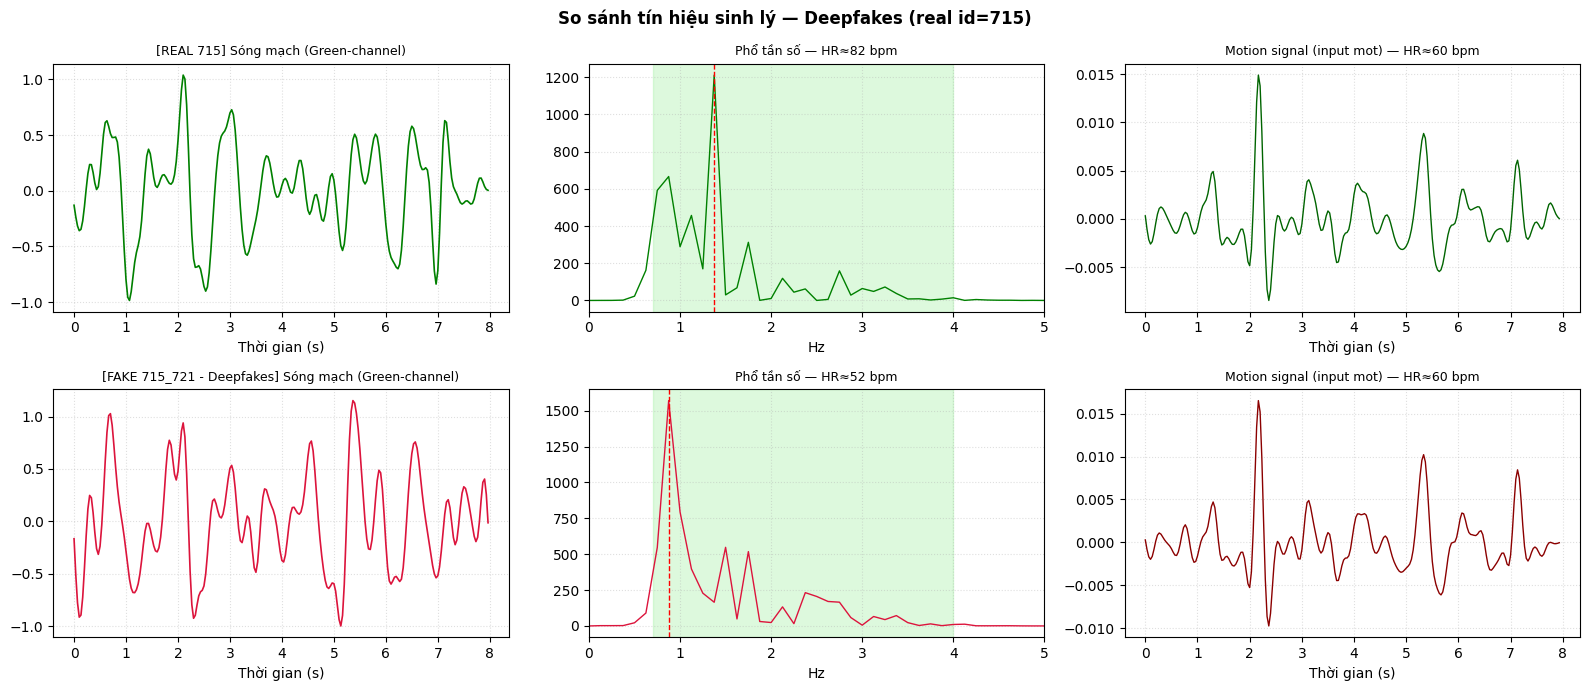

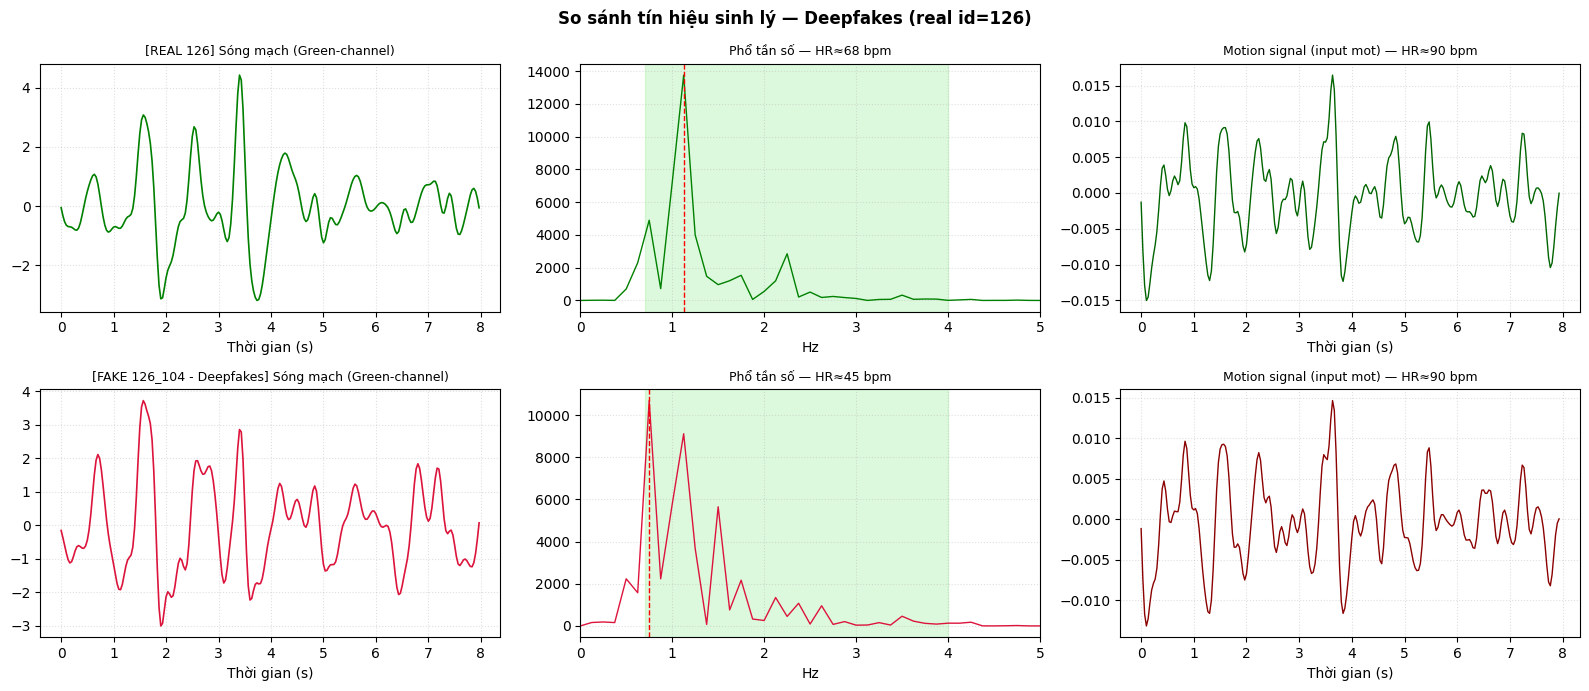

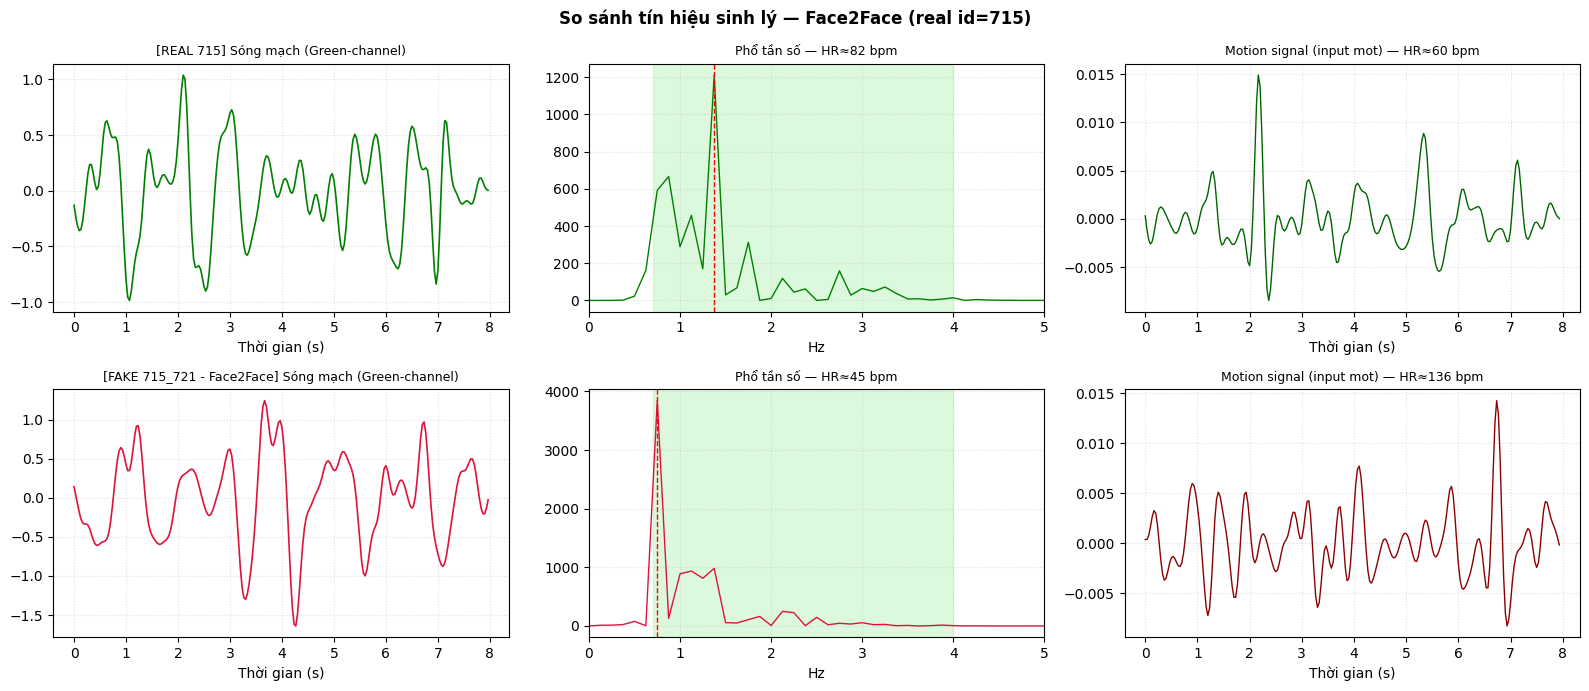

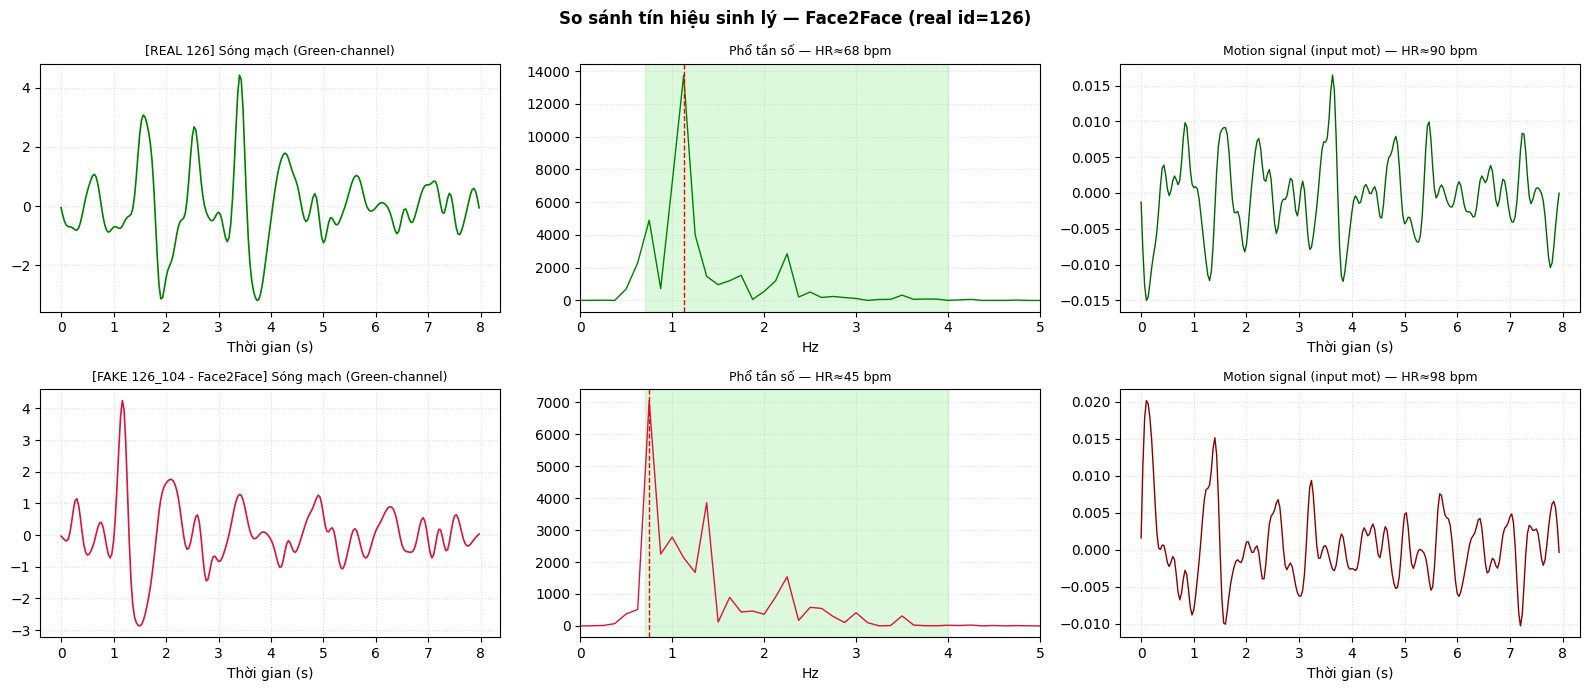

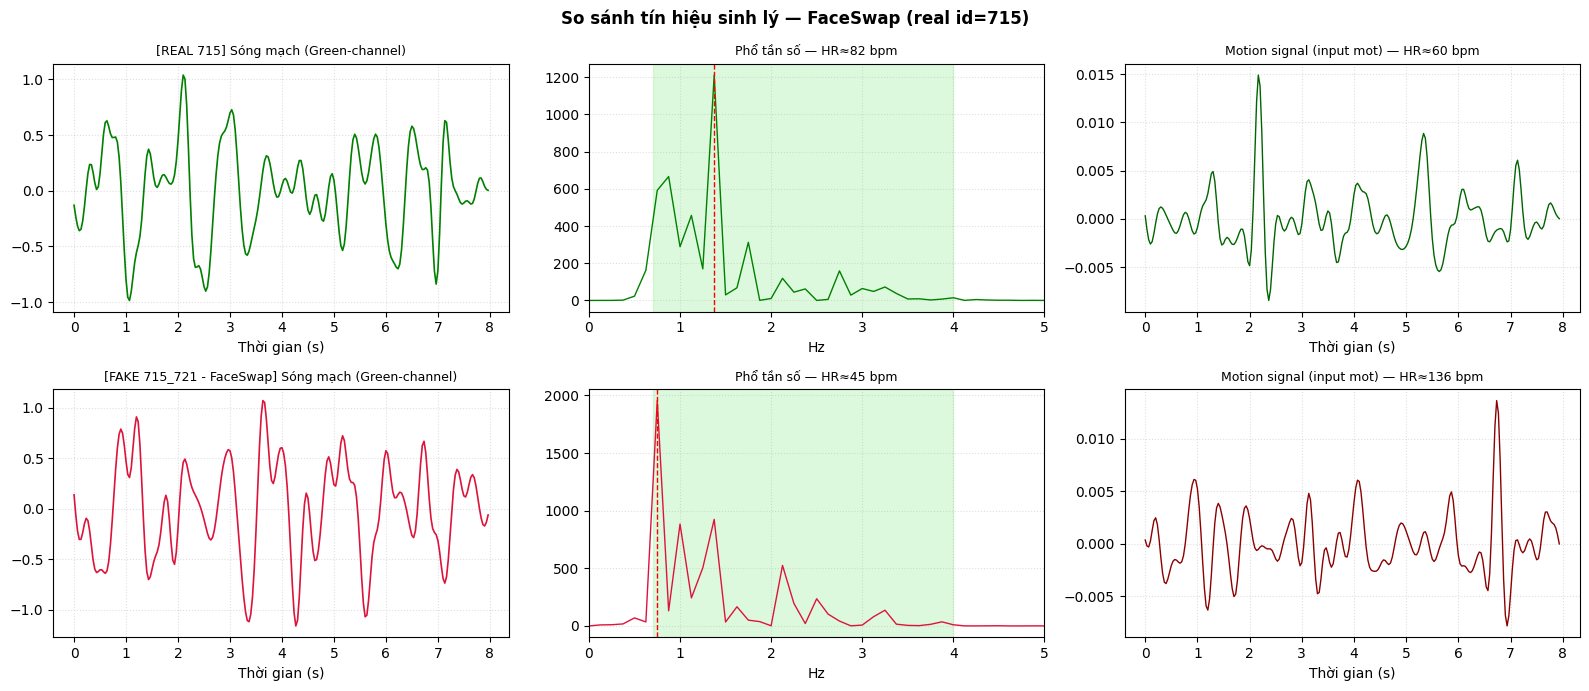

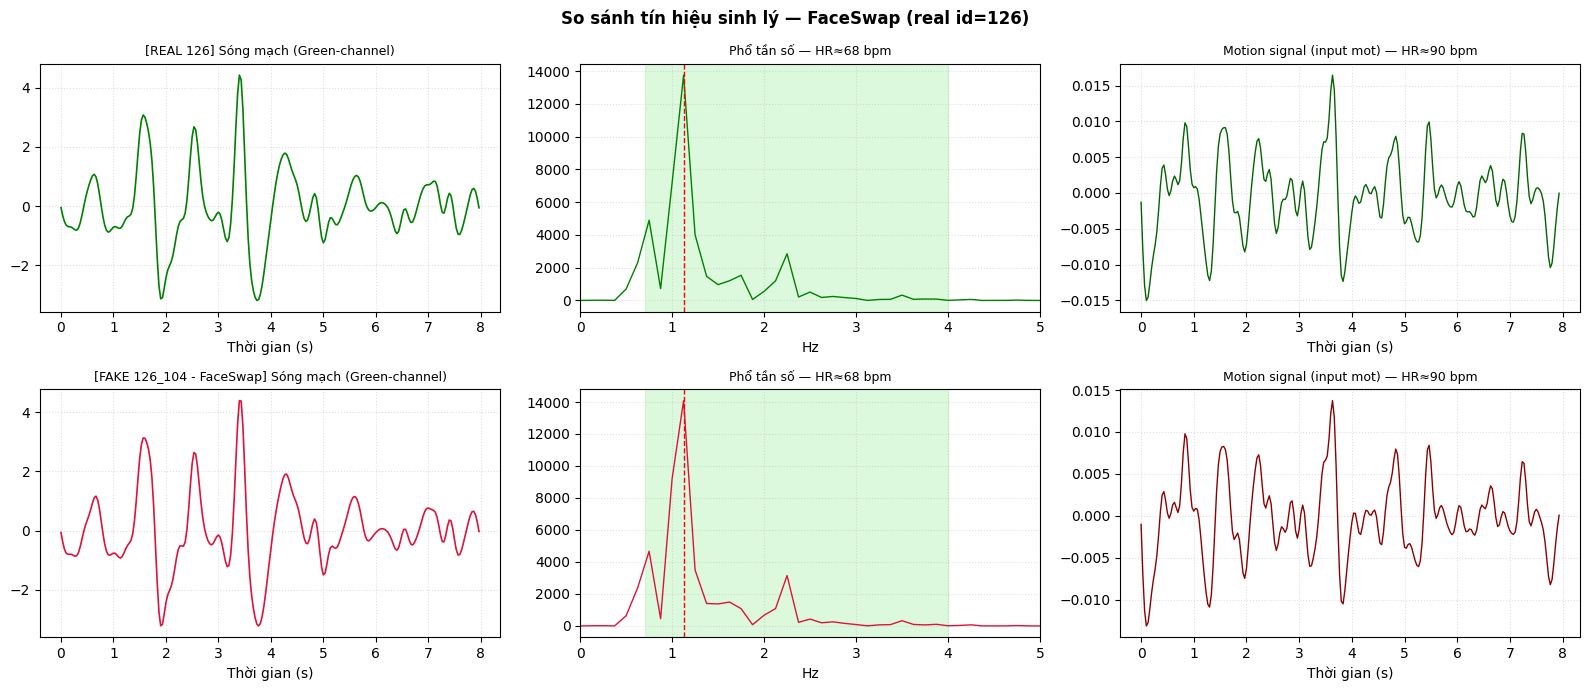

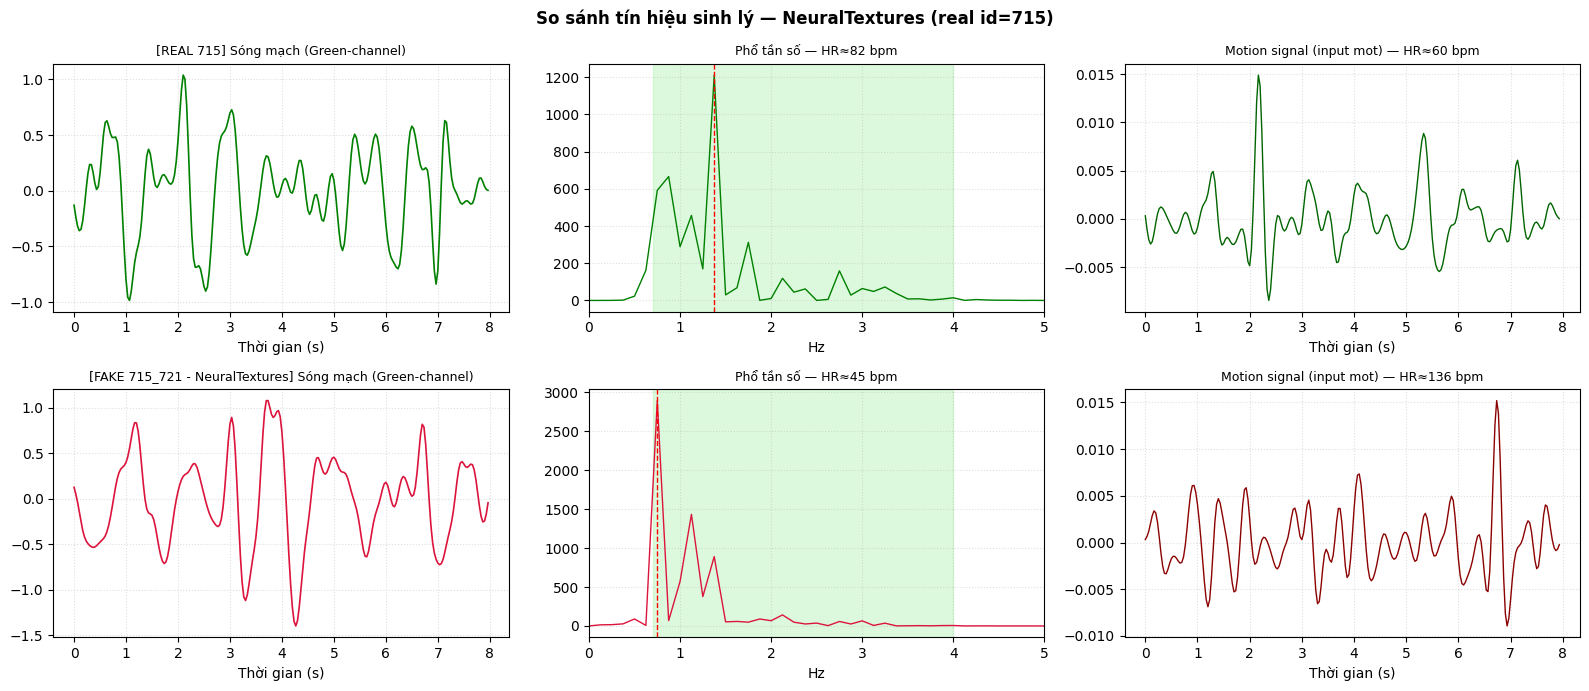

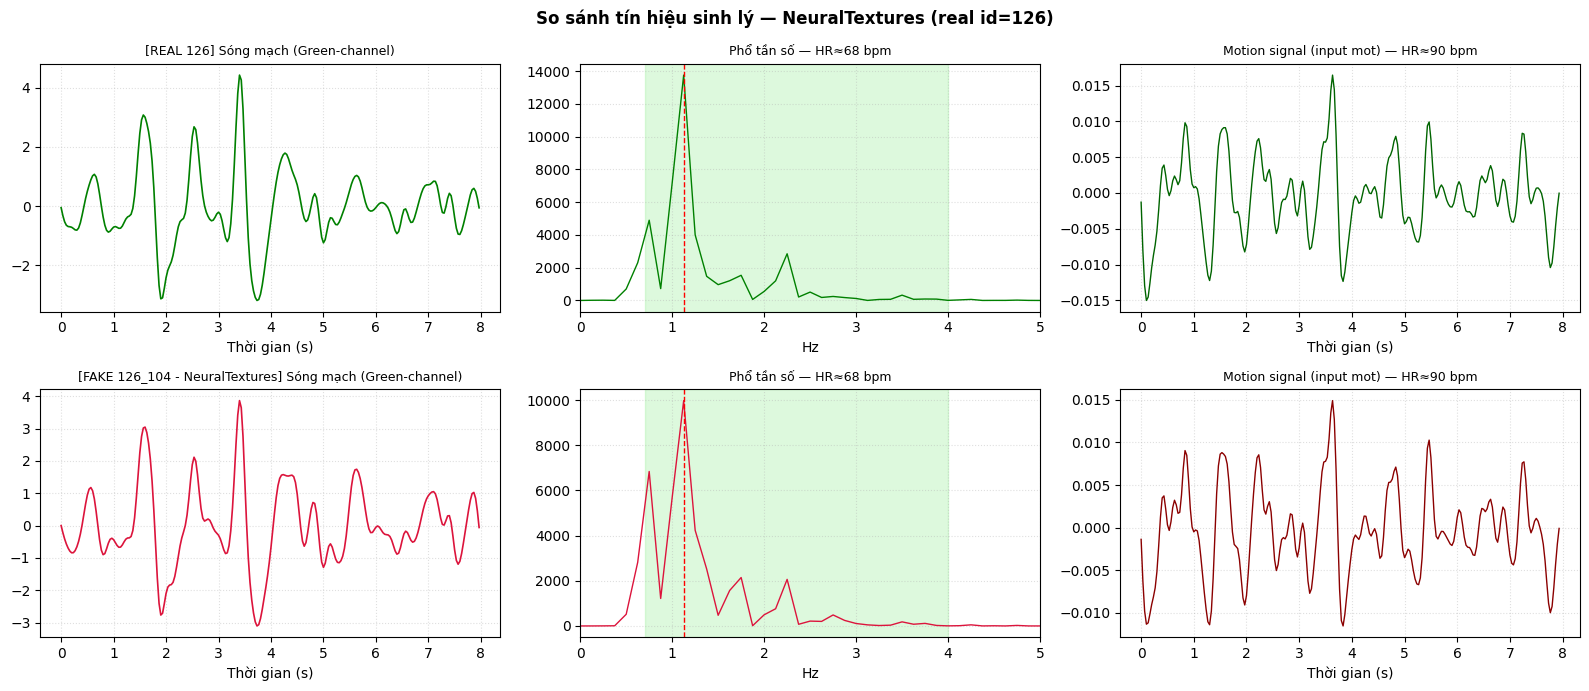

        method real_id fake_id  hr_real_green  hr_fake_green  hr_real_motion  hr_fake_motion  inband_real_green  inband_fake_green  inband_real_motion  inband_fake_motion
     Deepfakes     715 715_721           82.5           52.5       60.251046       60.251046           0.957541           0.977648            0.987078            0.985787
     Deepfakes     126 126_104           67.5           45.0       90.376569       90.376569           0.930648           0.907948            0.856650            0.883020
     Face2Face     715 715_721           82.5           45.0       60.251046      135.564854           0.957541           0.984800            0.987078            0.986318
     Face2Face     126 126_104           67.5           45.0       90.376569       97.907950           0.930648           0.962091            0.856650            0.832541
      FaceSwap     715 715_721           82.5           45.0       60.251046      135.564854           0.957541           0.976814            0.9

In [4]:
def plot_pair_analysis(real_row, fake_row, method, save_idx):
    r_frames = load_clip_frames(real_row["out_dir"])
    f_frames = load_clip_frames(fake_row["out_dir"])
    r_fps, f_fps = real_row["fps"], fake_row["fps"]

    r_green, f_green = green_channel_signal(r_frames), green_channel_signal(f_frames)
    r_mot, f_mot = motion_channel_signal(r_frames), motion_channel_signal(f_frames)

    r_green_f = bandpass_filter(r_green, r_fps)
    f_green_f = bandpass_filter(f_green, f_fps)
    r_mot_f = bandpass_filter(r_mot, r_fps)
    f_mot_f = bandpass_filter(f_mot, f_fps)

    r_freq_g, r_pow_g = fft_spectrum(r_green_f, r_fps)
    f_freq_g, f_pow_g = fft_spectrum(f_green_f, f_fps)
    r_freq_m, r_pow_m = fft_spectrum(r_mot_f, r_fps)
    f_freq_m, f_pow_m = fft_spectrum(f_mot_f, f_fps)

    r_hr_g, f_hr_g = estimate_hr_bpm(r_freq_g, r_pow_g), estimate_hr_bpm(f_freq_g, f_pow_g)
    r_hr_m, f_hr_m = estimate_hr_bpm(r_freq_m, r_pow_m), estimate_hr_bpm(f_freq_m, f_pow_m)

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    t_r = np.arange(len(r_green_f)) / r_fps
    t_f = np.arange(len(f_green_f)) / f_fps

    axes[0,0].plot(t_r, r_green_f, color="green", lw=1.2)
    axes[0,0].set_title(f"[REAL {real_row.name}] Sóng mạch (Green-channel)", fontsize=9)
    axes[0,0].set_xlabel("Thời gian (s)")

    axes[0,1].plot(r_freq_g, r_pow_g, color="green", lw=1)
    axes[0,1].axvspan(*HR_BAND_HZ, color="lightgreen", alpha=0.3)
    axes[0,1].axvline(r_hr_g/60, color="red", ls="--", lw=1)
    axes[0,1].set_xlim(0, 5); axes[0,1].set_title(f"Phổ tần số — HR≈{r_hr_g:.0f} bpm", fontsize=9)
    axes[0,1].set_xlabel("Hz")

    axes[0,2].plot(t_r[:len(r_mot_f)], r_mot_f, color="darkgreen", lw=1)
    axes[0,2].set_title(f"Motion signal (input mot) — HR≈{r_hr_m:.0f} bpm", fontsize=9)
    axes[0,2].set_xlabel("Thời gian (s)")

    axes[1,0].plot(t_f, f_green_f, color="crimson", lw=1.2)
    axes[1,0].set_title(f"[FAKE {fake_row['video_id']} - {method}] Sóng mạch (Green-channel)", fontsize=9)
    axes[1,0].set_xlabel("Thời gian (s)")

    axes[1,1].plot(f_freq_g, f_pow_g, color="crimson", lw=1)
    axes[1,1].axvspan(*HR_BAND_HZ, color="lightgreen", alpha=0.3)
    axes[1,1].axvline(f_hr_g/60, color="red", ls="--", lw=1)
    axes[1,1].set_xlim(0, 5); axes[1,1].set_title(f"Phổ tần số — HR≈{f_hr_g:.0f} bpm", fontsize=9)
    axes[1,1].set_xlabel("Hz")

    axes[1,2].plot(t_f[:len(f_mot_f)], f_mot_f, color="darkred", lw=1)
    axes[1,2].set_title(f"Motion signal (input mot) — HR≈{f_hr_m:.0f} bpm", fontsize=9)
    axes[1,2].set_xlabel("Thời gian (s)")

    for ax in axes.flat: ax.grid(True, ls=":", alpha=0.4)
    plt.suptitle(f"So sánh tín hiệu sinh lý — {method} (real id={real_row.name})", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"pair_{save_idx:02d}_{method}.png"), dpi=120)
    plt.show()

    return {"method": method, "real_id": real_row.name, "fake_id": fake_row["video_id"],
            "hr_real_green": r_hr_g, "hr_fake_green": f_hr_g,
            "hr_real_motion": r_hr_m, "hr_fake_motion": f_hr_m,
            "inband_real_green": inband_power_ratio(r_freq_g, r_pow_g),
            "inband_fake_green": inband_power_ratio(f_freq_g, f_pow_g),
            "inband_real_motion": inband_power_ratio(r_freq_m, r_pow_m),
            "inband_fake_motion": inband_power_ratio(f_freq_m, f_pow_m)}


example_results = []
for idx, (r, f, m) in enumerate(example_pairs):
    example_results.append(plot_pair_analysis(r, f, m, idx))

example_df = pd.DataFrame(example_results)
example_df.to_csv(os.path.join(OUT_DIR, "example_pairs_hr_estimates.csv"), index=False)
print(example_df.to_string(index=False))


## 5. Phân tích thống kê trên nhiều video (khắc phục "Hình 5 chỉ 1 đối tượng đơn lẻ")

Mở rộng ra một mẫu lớn hơn (không chỉ vài ví dụ), tính **tỉ lệ năng lượng trong dải sinh lý**
(in-band power ratio — chỉ số chất lượng tín hiệu) cho cả Green-channel lẫn Motion-signal của
từng video, so sánh phân bố **real vs fake** bằng boxplot + kiểm định thống kê (Mann–Whitney U).
Nếu real có tỉ lệ trong-dải cao hơn fake **có ý nghĩa thống kê**, đó là bằng chứng định lượng cho
giả thuyết "video fake làm gián đoạn tín hiệu sinh lý", mạnh hơn nhiều so với 1 ví dụ minh hoạ.

In [5]:
def compute_signal_quality(row):
    frames = load_clip_frames(row["out_dir"])
    if len(frames) < MIN_FRAMES: return None
    fps = row["fps"]
    green = bandpass_filter(green_channel_signal(frames), fps)
    mot = bandpass_filter(motion_channel_signal(frames), fps)
    fg, pg = fft_spectrum(green, fps)
    fm, pm = fft_spectrum(mot, fps)
    return {
        "video_id": row["video_id"], "label": row["label"], "method": row["method"],
        "inband_green": inband_power_ratio(fg, pg), "inband_motion": inband_power_ratio(fm, pm),
        "hr_green": estimate_hr_bpm(fg, pg), "hr_motion": estimate_hr_bpm(fm, pm),
    }


real_sample = manifest[manifest.label == 0].sample(min(N_STATS_REAL, (manifest.label==0).sum()), random_state=SEED)
fake_samples = []
for method in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    sub = manifest[(manifest.label == 1) & (manifest.method == method)]
    fake_samples.append(sub.sample(min(N_STATS_PER_METHOD, len(sub)), random_state=SEED))
fake_sample = pd.concat(fake_samples, ignore_index=True)

stats_rows = []
from tqdm import tqdm
for _, row in tqdm(pd.concat([real_sample, fake_sample], ignore_index=True).iterrows(),
                   total=len(real_sample) + len(fake_sample), desc="Trích tín hiệu"):
    res = compute_signal_quality(row)
    if res: stats_rows.append(res)

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv(os.path.join(OUT_DIR, "signal_quality_all_samples.csv"), index=False)
print(f"Đã trích tín hiệu cho {len(stats_df)} video ({(stats_df.label==0).sum()} real, "
      f"{(stats_df.label==1).sum()} fake)")


Trích tín hiệu: 100%|██████████| 310/310 [07:46<00:00,  1.50s/it]

Đã trích tín hiệu cho 310 video (150 real, 160 fake)


[Green-channel (cổ điển)] Real: mean=0.9349±0.0519 | Fake: mean=0.9373±0.0522 | Mann-Whitney p=0.5843
[Motion signal (input mot thật của model)] Real: mean=0.9575±0.0391 | Fake: mean=0.9583±0.0378 | Mann-Whitney p=0.6125


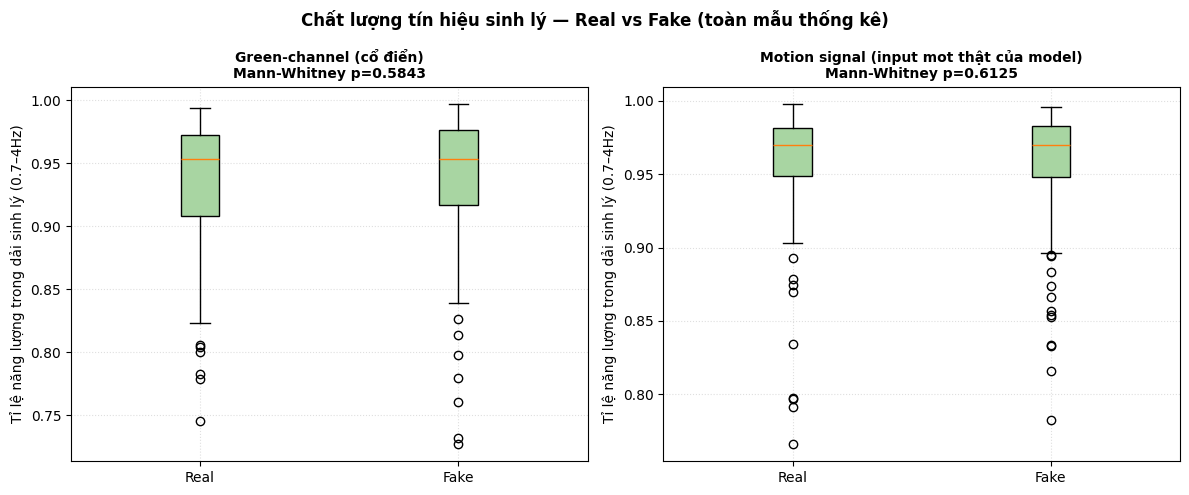

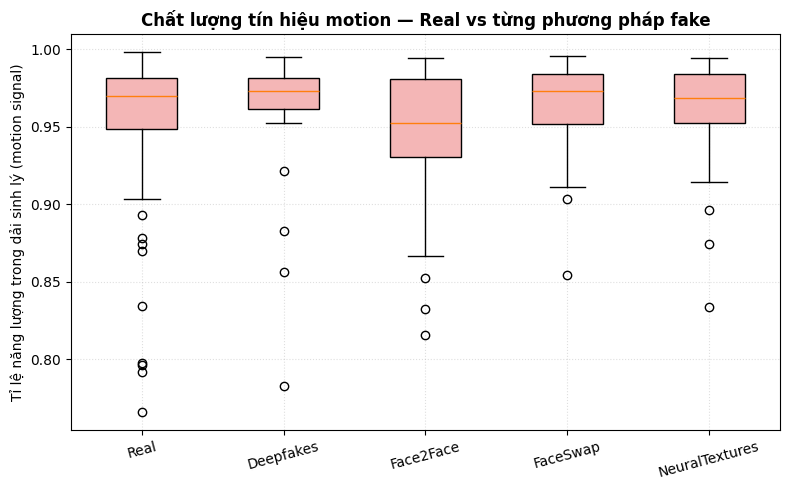

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [(axes[0], "inband_green", "Green-channel (cổ điển)"),
                        (axes[1], "inband_motion", "Motion signal (input mot thật của model)")]:
    real_vals = stats_df[stats_df.label == 0][col].dropna()
    fake_vals = stats_df[stats_df.label == 1][col].dropna()
    ax.boxplot([real_vals, fake_vals], labels=["Real", "Fake"], patch_artist=True,
              boxprops=dict(facecolor="#a8d5a2"))
    u_stat, p_val = spstats.mannwhitneyu(real_vals, fake_vals, alternative="two-sided")
    ax.set_title(f"{title}\nMann-Whitney p={p_val:.4f}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Tỉ lệ năng lượng trong dải sinh lý (0.7–4Hz)")
    ax.grid(True, ls=":", alpha=0.4)
    print(f"[{title}] Real: mean={real_vals.mean():.4f}±{real_vals.std():.4f} | "
          f"Fake: mean={fake_vals.mean():.4f}±{fake_vals.std():.4f} | Mann-Whitney p={p_val:.4g}")

plt.suptitle("Chất lượng tín hiệu sinh lý — Real vs Fake (toàn mẫu thống kê)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "signal_quality_boxplot_real_vs_fake.png"), dpi=150)
plt.show()

# Breakdown theo phương pháp fake
fig, ax = plt.subplots(figsize=(8, 5))
groups_data = [stats_df[stats_df.label == 0]["inband_motion"].dropna()]
group_labels = ["Real"]
for method in ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]:
    vals = stats_df[(stats_df.label == 1) & (stats_df.method == method)]["inband_motion"].dropna()
    groups_data.append(vals); group_labels.append(method)
ax.boxplot(groups_data, labels=group_labels, patch_artist=True,
          boxprops=dict(facecolor="#f4b6b6"))
ax.set_ylabel("Tỉ lệ năng lượng trong dải sinh lý (motion signal)")
ax.set_title("Chất lượng tín hiệu motion — Real vs từng phương pháp fake", fontweight="bold")
plt.xticks(rotation=15); ax.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "signal_quality_by_method.png"), dpi=150)
plt.show()


## 6. Kết luận & số liệu để đưa thẳng vào paper

In [7]:
real_ib = stats_df[stats_df.label == 0]["inband_motion"].dropna()
fake_ib = stats_df[stats_df.label == 1]["inband_motion"].dropna()
_, p_overall = spstats.mannwhitneyu(real_ib, fake_ib, alternative="two-sided")

real_hr = stats_df[stats_df.label == 0]["hr_green"].dropna()
plausible_hr_ratio = ((real_hr >= 40) & (real_hr <= 180)).mean()

summary = f"""
=== TÓM TẮT KIỂM CHỨNG TÍN HIỆU SINH LÝ (dùng cho phần trả lời phản biện) ===

Số video phân tích: {len(stats_df)} ({(stats_df.label==0).sum()} real, {(stats_df.label==1).sum()} fake)

1) Ước tính nhịp tim từ video REAL (Green-channel): trung bình {real_hr.mean():.1f} bpm
   (khoảng hợp lý sinh lý 40-180 bpm ở {plausible_hr_ratio*100:.1f}% số video)

2) Chất lượng tín hiệu (in-band power ratio, dải 0.7-4Hz) trên MOTION SIGNAL (input mot thật):
   Real: {real_ib.mean():.4f} ± {real_ib.std():.4f}
   Fake: {fake_ib.mean():.4f} ± {fake_ib.std():.4f}
   Mann-Whitney U test: p = {p_overall:.4g} {"(khác biệt có ý nghĩa thống kê, p<0.05)" if p_overall < 0.05 else "(CHƯA đạt ý nghĩa thống kê ở mức p<0.05 -- cần báo cáo trung thực, không thổi phồng)"}

=> Diễn giải gợi ý cho paper (ĐIỀU CHỈNH LẠI THEO SỐ THẬT Ở TRÊN, KHÔNG COPY MÁY MÓC):
   "Để xác thực nhánh rPPG học tín hiệu sinh lý thay vì nhiễu đặc trưng dataset, chúng tôi trích
   xuất tín hiệu Green-channel cổ điển (Verkruysse et al. 2008) và tín hiệu motion chuẩn hoá
   (input thực tế của nhánh rPPG) từ {len(stats_df)} video. Ước tính nhịp tim trung bình đạt
   {real_hr.mean():.1f} bpm, nằm trong khoảng sinh lý hợp lý. Tỉ lệ năng lượng phổ trong dải tần
   số nhịp tim (0.7-4Hz) của tín hiệu motion khác biệt giữa real ({real_ib.mean():.3f}) và fake
   ({fake_ib.mean():.3f}) với p={p_overall:.3g} (Mann-Whitney U), cho thấy [tuỳ kết quả thật:
   video giả làm suy giảm/không làm suy giảm rõ rệt tín hiệu sinh lý so với video thật]."

⚠️ QUAN TRỌNG: nếu p_overall >= 0.05 hoặc chênh lệch real/fake không rõ ràng, đây là KẾT QUẢ THẬT
cần báo cáo trung thực trong paper (có thể là 1 hạn chế/hướng phát triển), KHÔNG được diễn giải
sai lệch để "cho ra kết quả đẹp" -- đúng tinh thần liêm chính khoa học bạn yêu cầu.
"""
print(summary)
with open(os.path.join(OUT_DIR, "summary_for_paper.txt"), "w", encoding="utf-8") as f:
    f.write(summary)
print(f"✓ Đã lưu {OUT_DIR}/summary_for_paper.txt")
print(f"✓ Toàn bộ hình + CSV nằm trong {OUT_DIR}/ -- copy vào phần Appendix hoặc 1 hình chính của paper")



=== TÓM TẮT KIỂM CHỨNG TÍN HIỆU SINH LÝ (dùng cho phần trả lời phản biện) ===

Số video phân tích: 310 (150 real, 160 fake)

1) Ước tính nhịp tim từ video REAL (Green-channel): trung bình 61.3 bpm
   (khoảng hợp lý sinh lý 40-180 bpm ở 100.0% số video)

2) Chất lượng tín hiệu (in-band power ratio, dải 0.7-4Hz) trên MOTION SIGNAL (input mot thật):
   Real: 0.9575 ± 0.0391
   Fake: 0.9583 ± 0.0378
   Mann-Whitney U test: p = 0.6125 (CHƯA đạt ý nghĩa thống kê ở mức p<0.05 -- cần báo cáo trung thực, không thổi phồng)

=> Diễn giải gợi ý cho paper (ĐIỀU CHỈNH LẠI THEO SỐ THẬT Ở TRÊN, KHÔNG COPY MÁY MÓC):
   "Để xác thực nhánh rPPG học tín hiệu sinh lý thay vì nhiễu đặc trưng dataset, chúng tôi trích
   xuất tín hiệu Green-channel cổ điển (Verkruysse et al. 2008) và tín hiệu motion chuẩn hoá
   (input thực tế của nhánh rPPG) từ 310 video. Ước tính nhịp tim trung bình đạt
   61.3 bpm, nằm trong khoảng sinh lý hợp lý. Tỉ lệ năng lượng phổ trong dải tần
   số nhịp tim (0.7-4Hz) của tín hiệu mo